# Análisis Exploratorio de Datos v2

Este notebook conserva el flujo del original, pero concentra la lógica repetitiva en `src/features/transaction_eda.py`.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists():
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.notebook_common import ensure_project_root_on_path, env_flag, env_int, env_int_list, append_suffix

PROJECT_ROOT = ensure_project_root_on_path(Path.cwd())

from src.features.transaction_eda import (
    build_core_eda_outputs,
    build_errors_risk_summary,
    build_numeric_correlation_sample,
    fraud_rate_by_group,
    get_transaction_eda_paths,
    load_raw_transactions,
    prepare_transaction_eda_frame,
    top_volume_and_risk_by_group,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.4f}".format)

USE_SAMPLE = env_flag("FFDM_SAMPLE_RUN", False)
SAMPLE_ROWS = env_int("FFDM_SAMPLE_ROWS", 50000)
SAMPLE_ROW_GROUPS = env_int_list("FFDM_SAMPLE_ROW_GROUPS", [0])
SAVE_OUTPUTS = env_flag("FFDM_SAVE_OUTPUTS", True)
OUTPUT_SUFFIX = "_sample_v2" if USE_SAMPLE else ""

PATHS = get_transaction_eda_paths(PROJECT_ROOT)


In [2]:
raw_df = load_raw_transactions(
    PATHS,
    use_sample=USE_SAMPLE,
    sample_row_groups=SAMPLE_ROW_GROUPS,
    sample_rows=SAMPLE_ROWS,
)

errors_risk_summary = build_errors_risk_summary(raw_df)
df_cards = prepare_transaction_eda_frame(raw_df)
core_outputs = build_core_eda_outputs(df_cards)

if SAVE_OUTPUTS:
    clean_output = append_suffix(PATHS.clean_parquet, OUTPUT_SUFFIX)
    df_cards.to_parquet(clean_output, index=False)
    print(f"Base limpia guardada en: {clean_output}")

print(f"USE_SAMPLE={USE_SAMPLE} | filas={len(df_cards):,} | columnas={df_cards.shape[1]}")


Base limpia guardada en: C:\Users\cecor\OneDrive - Universidad Nacional de Colombia\GitHub\MSc-Thesis-Financial-Fraud-Detection-Models\data\processed\card_transactions_clean_sample_v2.parquet
USE_SAMPLE=True | filas=1,048,576 | columnas=23


In [3]:
display(df_cards.head(3))
display(core_outputs["unique_null_summary"].head(20))
display(core_outputs["null_summary"].head(20))
display(core_outputs["duplicate_summary"])
display(errors_risk_summary.head(20))
display(core_outputs["target_distribution"])


,user,card,year,month,day,time,amount,use_chip,merchant_name,merchant_city,merchant_state,zip,mcc,is_fraud,merchant_state_was_missing,zip_was_missing,user_card_id,amount_is_negative,amount_abs,hour,datetime,day_of_week,is_weekend
0,0,0,2002,9,1,06:21,134.0900,Swipe Transaction,3527213246127876953,La Verne,CA,91750,5300,0,0,0,0_0,0,134.0900,6,2002-09-01 06:21:00,6,1
1,0,0,2002,9,1,06:42,38.4800,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754,5411,0,0,0,0_0,0,38.4800,6,2002-09-01 06:42:00,6,1
2,0,0,2002,9,2,06:22,120.3400,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754,5411,0,0,0,0_0,0,120.3400,6,2002-09-02 06:22:00,0,0


,column,dtype,unique_values,missing_values,missing_percentage
0,datetime,datetime64[ns],968984,0,0.0000
1,amount,float64,33397,0,0.0000
2,amount_abs,float64,32931,0,0.0000
3,merchant_name,string,10859,0,0.0000
4,zip,object,9303,0,0.0000
5,merchant_city,string,5034,0,0.0000
6,time,string,1440,0,0.0000
7,user_card_id,string,231,0,0.0000
8,merchant_state,object,122,0,0.0000
9,mcc,string,109,0,0.0000


,column,null_count,null_percentage
0,user,0,0.0000
1,card,0,0.0000
2,year,0,0.0000
3,month,0,0.0000
4,day,0,0.0000
5,time,0,0.0000
6,amount,0,0.0000
7,use_chip,0,0.0000
8,merchant_name,0,0.0000
9,merchant_city,0,0.0000


,metric,value
0,duplicated_rows,9.0000
1,duplicated_percentage,0.0009


,error_clean,count,fraud_count,fraud_rate


,is_fraud,count,proportion
0,0,1047527,0.9990
1,1,1049,0.0010


,is_fraud,count,mean,median,std,min,max
0,0,1047527,45.4776,32.0700,84.4481,-500.0000,"6,820.2000"
1,1,1049,116.8949,71.0600,238.9732,-500.0000,"3,750.6000"


,is_fraud,quantile,amount
0,0,0.0100,-95.0000
1,0,0.0500,0.3800
2,0,0.2500,10.7600
3,0,0.5000,32.0700
4,0,0.7500,65.8300
5,0,0.9500,146.2500
6,0,0.9900,306.0000
7,1,0.0100,-369.4400
8,1,0.0500,0.3740
9,1,0.2500,19.2800


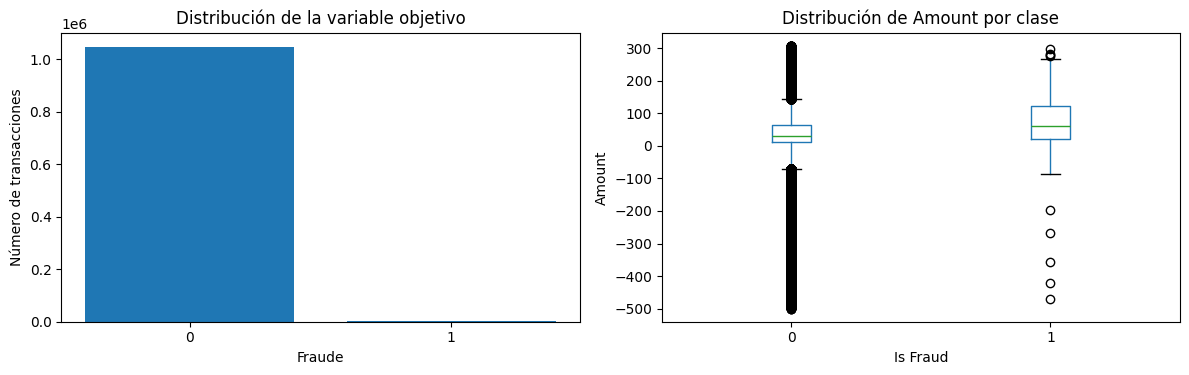

In [4]:
display(core_outputs["amount_by_target"])
display(core_outputs["amount_quantiles_by_target"])

amount_boxplot_sample = df_cards.loc[df_cards["amount"] <= df_cards["amount"].quantile(0.99), ["is_fraud", "amount"]]
if len(amount_boxplot_sample) > 200_000:
    amount_boxplot_sample = amount_boxplot_sample.sample(n=200_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(core_outputs["target_distribution"]["is_fraud"].astype(str), core_outputs["target_distribution"]["count"])
axes[0].set_title("Distribución de la variable objetivo")
axes[0].set_xlabel("Fraude")
axes[0].set_ylabel("Número de transacciones")

amount_boxplot_sample.boxplot(column="amount", by="is_fraud", grid=False, ax=axes[1])
axes[1].set_title("Distribución de Amount por clase")
axes[1].set_xlabel("Is Fraud")
axes[1].set_ylabel("Amount")
fig.suptitle("")
fig.tight_layout()
plt.show()


In [5]:
fraud_by_weekend = core_outputs["fraud_by_weekend"].copy()
fraud_by_weekend["period_type"] = fraud_by_weekend["is_weekend"].map({0: "Día hábil", 1: "Fin de semana"})

merchant_state_top, merchant_state_risk = top_volume_and_risk_by_group(df_cards, "merchant_state", min_count_for_risk=1000)
merchant_top, _ = top_volume_and_risk_by_group(df_cards, "merchant_name", min_count_for_risk=1000)
mcc_top, mcc_risk = top_volume_and_risk_by_group(df_cards, "mcc", min_count_for_risk=1000)

display(core_outputs["fraud_by_year"])
display(core_outputs["fraud_by_month"])
display(core_outputs["fraud_by_hour"])
display(fraud_by_weekend)
display(merchant_state_top.head(20))
display(merchant_state_risk.head(20))
display(mcc_top.head(20))
display(mcc_risk.head(20))
display(merchant_top.head(20))


,year,count,fraud_count,fraud_rate
0,1996,920,0,0.0000
1,1997,1225,0,0.0000
2,1998,3123,0,0.0000
3,1999,4800,6,0.0013
4,2000,7597,17,0.0022
5,2001,10637,15,0.0014
6,2002,18733,2,0.0001
7,2003,24592,0,0.0000
8,2004,27920,0,0.0000
9,2005,33087,2,0.0001


,month,count,fraud_count,fraud_rate
0,1,92816,64,0.0007
1,2,83855,73,0.0009
2,3,86313,110,0.0013
3,4,83480,109,0.0013
4,5,87021,83,0.0010
5,6,84864,96,0.0011
6,7,89257,55,0.0006
7,8,89198,126,0.0014
8,9,86203,71,0.0008
9,10,88584,84,0.0009


,hour,count,fraud_count,fraud_rate
0,0,6336,0,0.0000
1,1,3567,4,0.0011
2,2,11770,11,0.0009
3,3,6455,6,0.0009
4,4,9391,14,0.0015
5,5,9768,9,0.0009
6,6,63286,22,0.0003
7,7,72679,47,0.0006
8,8,67924,49,0.0007
9,9,73343,88,0.0012


,is_weekend,count,fraud_count,fraud_rate,period_type
0,0,748742,728,0.0010,Día hábil
1,1,299834,321,0.0011,Fin de semana


,merchant_state,count,fraud_count,fraud_rate
0,UNKNOWN,151427,545,0.0036
1,TX,126915,60,0.0005
2,CA,106588,26,0.0002
3,AZ,81086,11,0.0001
4,FL,59556,16,0.0003
5,AL,59364,1,0.0000
6,NY,49900,6,0.0001
7,MI,31520,3,0.0001
8,TN,30296,4,0.0001
9,PA,30272,3,0.0001


,merchant_state,count,fraud_count,fraud_rate
0,Mexico,1509,17,0.0113
1,UNKNOWN,151427,545,0.0036
2,GA,15506,12,0.0008
3,OH,24443,17,0.0007
4,CO,1908,1,0.0005
5,SC,16636,8,0.0005
6,TX,126915,60,0.0005
7,NJ,7139,3,0.0004
8,IN,2433,1,0.0004
9,WA,14777,6,0.0004


,mcc,count,fraud_count,fraud_rate
0,5411,116386,44,0.0004
1,5499,101812,6,0.0001
2,5541,98360,20,0.0002
3,5812,84829,8,0.0001
4,4784,79102,0,0.0000
5,5912,60980,39,0.0006
6,4121,51957,24,0.0005
7,4829,51885,55,0.0011
8,5300,47031,75,0.0016
9,5814,41855,17,0.0004


,mcc,count,fraud_count,fraud_rate
0,3722,1267,14,0.0110
1,3509,1307,13,0.0099
2,7011,1513,14,0.0093
3,3596,1157,9,0.0078
4,3640,1190,8,0.0067
5,3504,1250,8,0.0064
6,5651,5672,34,0.0060
7,5815,5504,30,0.0055
8,5719,6460,34,0.0053
9,5310,18070,80,0.0044


,merchant_name,count,fraud_count,fraud_rate
0,-4282466774399734331,51885,55,0.0011
1,1799189980464955940,46551,3,0.0001
2,-2088492411650162548,36820,0,0.0000
3,-5162038175624867091,33378,13,0.0004
4,4722913068560264812,28934,0,0.0000
5,2027553650310142703,27780,4,0.0001
6,1913477460590765860,23594,51,0.0022
7,-1688244360627004732,22031,0,0.0000
8,6666504894937430109,20440,0,0.0000
9,97032797689821735,19058,2,0.0001


,year,month,day,hour,amount,is_fraud
year,1.0000,-0.0542,-0.0005,-0.0080,-0.0133,0.0040
month,-0.0542,1.0000,0.0150,-0.0008,-0.0022,0.0004
day,-0.0005,0.0150,1.0000,0.0006,-0.0004,-0.0031
hour,-0.0080,-0.0008,0.0006,1.0000,0.0356,-0.0044
amount,-0.0133,-0.0022,-0.0004,0.0356,1.0000,0.0242
is_fraud,0.0040,0.0004,-0.0031,-0.0044,0.0242,1.0000


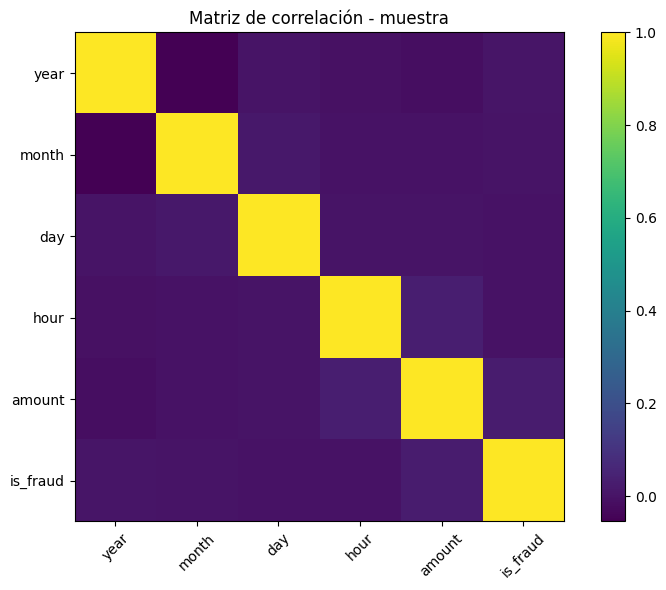

In [6]:
numeric_columns = ["year", "month", "day", "hour", "amount", "mcc", "is_fraud"]
correlation_matrix = build_numeric_correlation_sample(df_cards, numeric_columns=numeric_columns, max_rows=500000)
display(correlation_matrix)

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix)
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.colorbar()
plt.title("Matriz de correlación - muestra")
plt.tight_layout()
plt.show()
